In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv
from sklearn.metrics import precision_recall_curve
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Carica le variabili dal file .env
load_dotenv()

password = quote_plus(os.getenv("DB_PASSWORD"))
user     = os.getenv("DB_USER")
host     = os.getenv("DB_HOST")
db       = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+mysqlconnector://{user}:{password}@{host}/{db}"
)

print("✅ Connessione stabilita")

✅ Connessione stabilita


In [7]:
# ── Analisi metodi di pagamento ──────────────────────────────

query_payments = """
SELECT
    payment_type,
    COUNT(*)                     AS numero_transazioni,
    ROUND(AVG(payment_value), 2) AS valore_medio,
    ROUND(SUM(payment_value), 2) AS valore_totale
FROM order_payments
WHERE payment_type != 'not_defined'
GROUP BY payment_type
ORDER BY valore_totale DESC
"""

df_payments = pd.read_sql(query_payments, engine)
df_payments

,payment_type,numero_transazioni,valore_medio,valore_totale
0,credit_card,76795,163.32,12542084.19
1,boleto,19784,145.03,2869361.27
2,voucher,5775,65.70,379436.87
3,debit_card,1529,142.57,217989.79


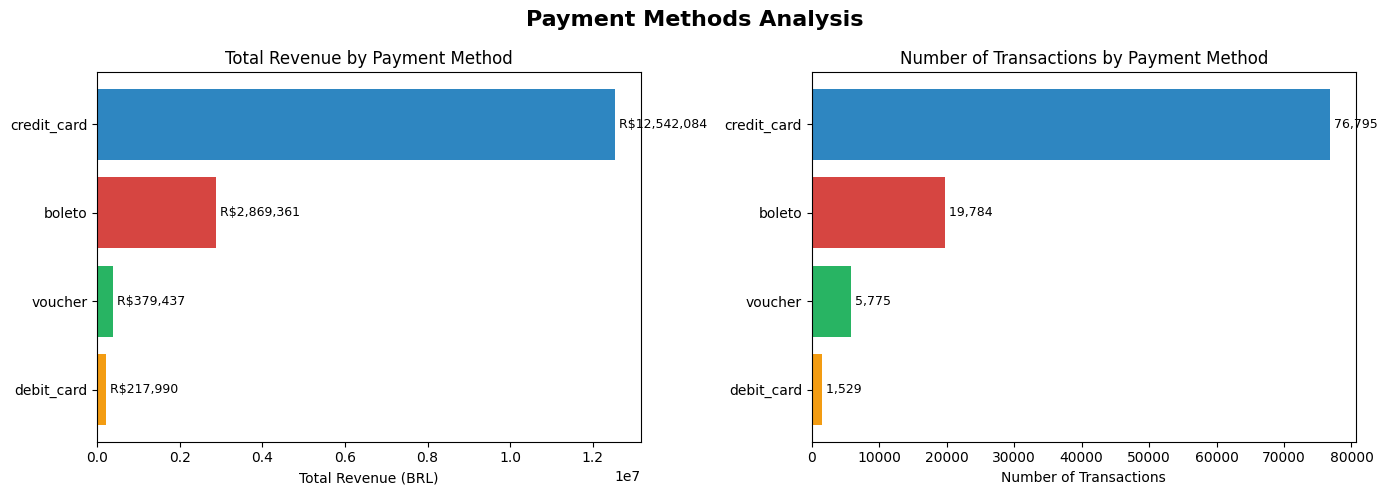

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Payment Methods Analysis", fontsize=16, fontweight="bold")

# ── Grafico 1 — Fatturato totale per metodo ──────────────────
axes[0].barh(
    df_payments["payment_type"],
    df_payments["valore_totale"],
    color=["#2E86C1", "#D64541", "#28B463", "#F39C12"]
)
axes[0].set_title("Total Revenue by Payment Method")
axes[0].set_xlabel("Total Revenue (BRL)")
axes[0].invert_yaxis()

# Aggiunge i valori sulle barre
for i, v in enumerate(df_payments["valore_totale"]):
    axes[0].text(v, i, f" R${v:,.0f}", va="center", fontsize=9)

# ── Grafico 2 — Numero transazioni per metodo ────────────────
axes[1].barh(
    df_payments["payment_type"],
    df_payments["numero_transazioni"],
    color=["#2E86C1", "#D64541", "#28B463", "#F39C12"]
)
axes[1].set_title("Number of Transactions by Payment Method")
axes[1].set_xlabel("Number of Transactions")
axes[1].invert_yaxis()

for i, v in enumerate(df_payments["numero_transazioni"]):
    axes[1].text(v, i, f" {v:,}", va="center", fontsize=9)

plt.tight_layout()
#plt.savefig("output/payments_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ── Analisi ritardi di consegna per stato ────────────────────

query_delivery = """
SELECT
    customer_state,
    COUNT(*)                                         AS numero_ordini,
    ROUND(AVG(DATEDIFF(
        order_delivered_customer_date,
        order_estimated_delivery_date)), 1)          AS ritardo_medio_giorni,
    ROUND(AVG(DATEDIFF(
        order_delivered_customer_date,
        order_purchase_timestamp)), 1)               AS giorni_medi_consegna,
    ROUND(100.0 * SUM(CASE
        WHEN order_delivered_customer_date > order_estimated_delivery_date
        THEN 1 ELSE 0 END) / COUNT(*), 1)            AS percentuale_ritardo
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE order_delivered_customer_date IS NOT NULL
GROUP BY customer_state
ORDER BY percentuale_ritardo DESC
"""

df_delivery = pd.read_sql(query_delivery, engine)
df_delivery

,customer_state,numero_ordini,ritardo_medio_giorni,giorni_medi_consegna,percentuale_ritardo
0,AL,397,-8.7,24.5,23.9
1,MA,717,-9.6,21.5,19.7
2,PI,476,-11.3,19.4,16.0
3,CE,1279,-10.8,21.2,15.3
4,SE,335,-10.0,21.5,15.2
5,BA,3256,-10.8,19.3,14.0
6,RJ,12353,-11.8,15.2,13.5
7,TO,274,-12.1,17.6,12.8
8,PA,946,-14.1,23.7,12.4
9,ES,1995,-10.5,15.7,12.2


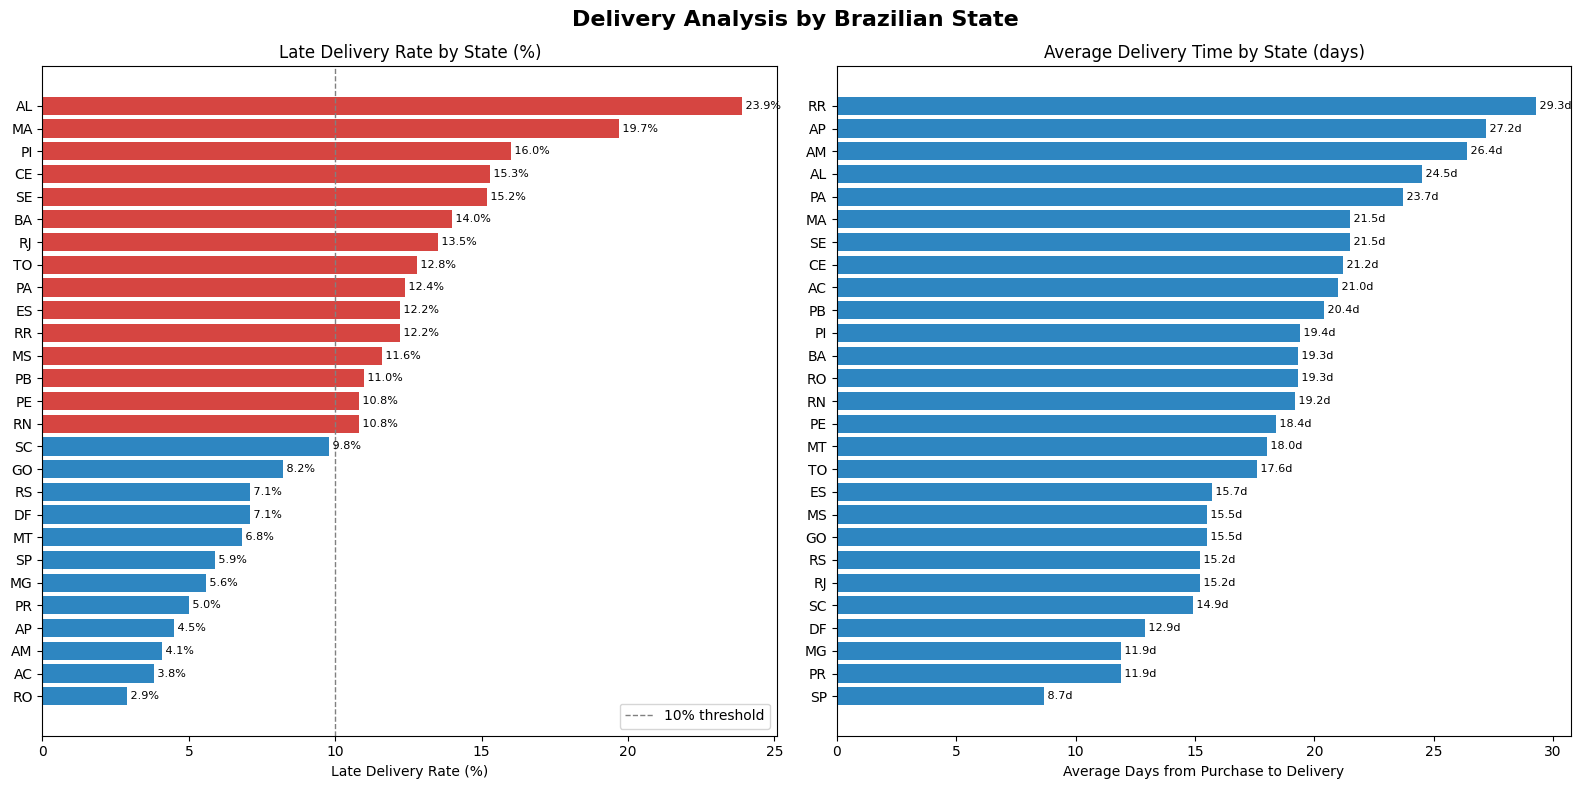

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Delivery Analysis by Brazilian State", fontsize=16, fontweight="bold")

# ── Grafico 1 — Percentuale ritardo per stato ────────────────
df_sorted = df_delivery.sort_values("percentuale_ritardo", ascending=True)

colors = ["#D64541" if x > 10 else "#2E86C1" for x in df_sorted["percentuale_ritardo"]]

axes[0].barh(
    df_sorted["customer_state"],
    df_sorted["percentuale_ritardo"],
    color=colors
)
axes[0].axvline(10, color="gray", linestyle="--", linewidth=1, label="10% threshold")
axes[0].set_title("Late Delivery Rate by State (%)")
axes[0].set_xlabel("Late Delivery Rate (%)")
axes[0].legend()

for i, v in enumerate(df_sorted["percentuale_ritardo"]):
    axes[0].text(v, i, f" {v}%", va="center", fontsize=8)

# ── Grafico 2 — Giorni medi di consegna per stato ────────────
df_sorted2 = df_delivery.sort_values("giorni_medi_consegna", ascending=True)

axes[1].barh(
    df_sorted2["customer_state"],
    df_sorted2["giorni_medi_consegna"],
    color="#2E86C1"
)
axes[1].set_title("Average Delivery Time by State (days)")
axes[1].set_xlabel("Average Days from Purchase to Delivery")

for i, v in enumerate(df_sorted2["giorni_medi_consegna"]):
    axes[1].text(v, i, f" {v}d", va="center", fontsize=8)

plt.tight_layout()
#plt.savefig("output/delivery_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Carica la shapefile degli stati brasiliani
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil_states = gpd.read_file(url)

# Vedi le colonne disponibili
print(brazil_states.columns.tolist())
print(brazil_states["sigla"].head())

['id', 'name', 'sigla', 'regiao_id', 'codigo_ibg', 'cartodb_id', 'created_at', 'updated_at', 'geometry']
0    AC
1    AL
2    AM
3    AP
4    BA
Name: sigla, dtype: object


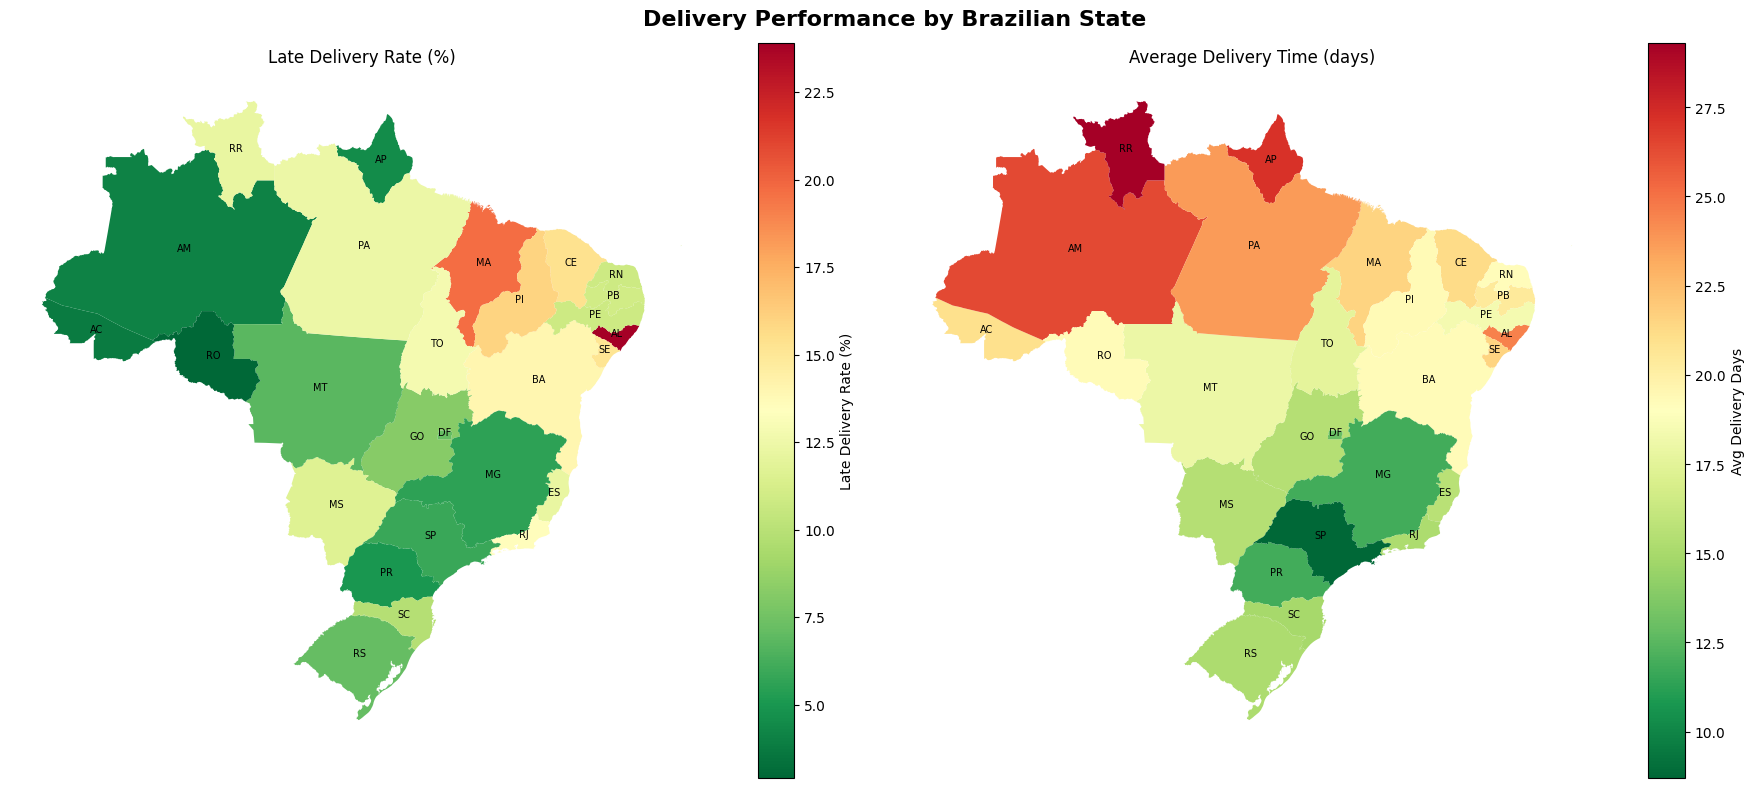

In [14]:
# Merge tra geodataframe e dati di consegna
brazil_merged = brazil_states.merge(
    df_delivery[["customer_state", "percentuale_ritardo", "giorni_medi_consegna"]],
    left_on="sigla",
    right_on="customer_state",
    how="left"
)

# ── Mappa — percentuale ritardo per stato ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Delivery Performance by Brazilian State", fontsize=16, fontweight="bold")

# Mappa 1 — percentuale ritardo
brazil_merged.plot(
    column="percentuale_ritardo",
    ax=axes[0],
    legend=True,
    cmap="RdYlGn_r",
    missing_kwds={"color": "lightgray"},
    legend_kwds={"label": "Late Delivery Rate (%)"}
)
axes[0].set_title("Late Delivery Rate (%)")
axes[0].axis("off")

# Aggiunge le sigle degli stati sulla mappa
for idx, row in brazil_merged.iterrows():
    if row["geometry"] is not None:
        axes[0].annotate(
            row["sigla"],
            xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
            ha="center", fontsize=7, color="black"
        )

# Mappa 2 — giorni medi di consegna
brazil_merged.plot(
    column="giorni_medi_consegna",
    ax=axes[1],
    legend=True,
    cmap="RdYlGn_r",
    missing_kwds={"color": "lightgray"},
    legend_kwds={"label": "Avg Delivery Days"}
)
axes[1].set_title("Average Delivery Time (days)")
axes[1].axis("off")

for idx, row in brazil_merged.iterrows():
    if row["geometry"] is not None:
        axes[1].annotate(
            row["sigla"],
            xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
            ha="center", fontsize=7, color="black"
        )

plt.tight_layout()
#plt.savefig("output/brazil_delivery_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# ── RFM Analysis ─────────────────────────────────────────────

query_rfm = """
WITH rfm_base AS (
    SELECT
        c.customer_unique_id,
        MAX(o.order_purchase_timestamp)      AS ultimo_acquisto,
        COUNT(DISTINCT o.order_id)           AS frequenza,
        ROUND(SUM(p.payment_value), 2)       AS spesa_totale
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_payments p
        ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
rfm_scores AS (
    SELECT
        customer_unique_id,
        ultimo_acquisto,
        frequenza,
        spesa_totale,
        NTILE(4) OVER (ORDER BY ultimo_acquisto DESC) AS r_score,
        NTILE(4) OVER (ORDER BY frequenza ASC)        AS f_score,
        NTILE(4) OVER (ORDER BY spesa_totale ASC)     AS m_score
    FROM rfm_base
),
rfm_segments AS (
    SELECT
        customer_unique_id,
        ultimo_acquisto,
        frequenza,
        spesa_totale,
        r_score,
        f_score,
        m_score,
        CONCAT(r_score, f_score, m_score) AS rfm_combined,
        CASE
            WHEN r_score = 4 AND f_score = 4 AND m_score = 4
                THEN 'Champions'
            WHEN r_score >= 3 AND f_score >= 3
                THEN 'Loyal Customers'
            WHEN r_score = 4 AND f_score <= 2
                THEN 'Recent Customers'
            WHEN r_score >= 3 AND m_score >= 3
                THEN 'Potential Loyalists'
            WHEN r_score <= 2 AND f_score >= 3 AND m_score >= 3
                THEN 'At Risk'
            WHEN r_score = 1 AND f_score = 1
                THEN 'Lost'
            ELSE
                'Needs Attention'
        END AS segmento
    FROM rfm_scores
)
SELECT
    segmento,
    COUNT(*)                         AS numero_clienti,
    ROUND(AVG(frequenza), 2)         AS freq_media,
    ROUND(AVG(spesa_totale), 2)      AS spesa_media,
    ROUND(SUM(spesa_totale), 2)      AS fatturato_totale
FROM rfm_segments
GROUP BY segmento
ORDER BY fatturato_totale DESC
"""

df_rfm = pd.read_sql(query_rfm, engine)
df_rfm

,segmento,numero_clienti,freq_media,spesa_media,fatturato_totale
0,At Risk,17333,1.09,264.77,4589201.80
1,Recent Customers,22758,1.00,161.04,3664970.34
2,Needs Attention,34857,1.00,101.79,3547993.62
3,Loyal Customers,12772,1.08,158.94,2030027.62
4,Potential Loyalists,5296,1.00,273.65,1449255.82
5,Champions,341,2.09,413.53,141012.57


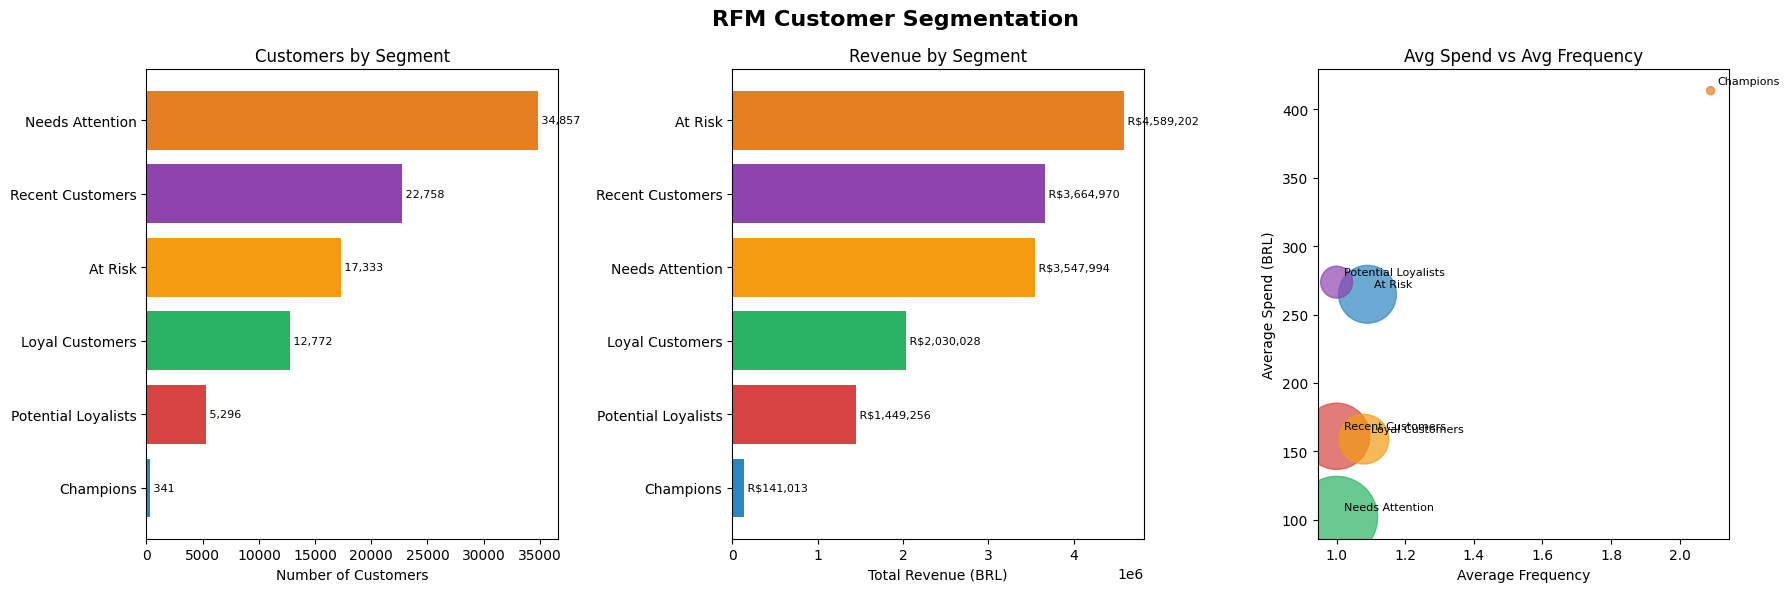

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("RFM Customer Segmentation", fontsize=16, fontweight="bold")

colors = ["#2E86C1", "#D64541", "#28B463", "#F39C12", "#8E44AD", "#E67E22", "#1ABC9C"]

# ── Grafico 1 — Numero clienti per segmento ──────────────────
df_rfm_sorted = df_rfm.sort_values("numero_clienti", ascending=True)
axes[0].barh(df_rfm_sorted["segmento"], df_rfm_sorted["numero_clienti"], color=colors)
axes[0].set_title("Customers by Segment")
axes[0].set_xlabel("Number of Customers")
for i, v in enumerate(df_rfm_sorted["numero_clienti"]):
    axes[0].text(v, i, f" {v:,}", va="center", fontsize=8)

# ── Grafico 2 — Fatturato per segmento ───────────────────────
df_rfm_sorted2 = df_rfm.sort_values("fatturato_totale", ascending=True)
axes[1].barh(df_rfm_sorted2["segmento"], df_rfm_sorted2["fatturato_totale"], color=colors)
axes[1].set_title("Revenue by Segment")
axes[1].set_xlabel("Total Revenue (BRL)")
for i, v in enumerate(df_rfm_sorted2["fatturato_totale"]):
    axes[1].text(v, i, f" R${v:,.0f}", va="center", fontsize=8)

# ── Grafico 3 — Spesa media vs frequenza media ────────────────
axes[2].scatter(
    df_rfm["freq_media"],
    df_rfm["spesa_media"],
    s=df_rfm["numero_clienti"] / 10,
    color=colors[:len(df_rfm)],
    alpha=0.7
)
for _, row in df_rfm.iterrows():
    axes[2].annotate(
        row["segmento"],
        xy=(row["freq_media"], row["spesa_media"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )
axes[2].set_title("Avg Spend vs Avg Frequency")
axes[2].set_xlabel("Average Frequency")
axes[2].set_ylabel("Average Spend (BRL)")

plt.tight_layout()
#plt.savefig("output/rfm_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ── Late Delivery Prediction — Data Preparation ──────────────

query_ml = """
SELECT
    o.order_id,
    c.customer_state,
    s.seller_state,
    p.product_category_name,
    p.product_weight_g,
    oi.price,
    oi.freight_value,
    op.payment_installments,
    DATEDIFF(
        o.order_estimated_delivery_date,
        o.order_purchase_timestamp
    )                                           AS giorni_stimati_consegna,
    CASE
        WHEN c.customer_state = s.seller_state
        THEN 1 ELSE 0
    END                                         AS stesso_stato,
    CASE
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
        THEN 1 ELSE 0
    END                                         AS in_ritardo
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN products p
    ON oi.product_id = p.product_id
JOIN sellers s
    ON oi.seller_id = s.seller_id
JOIN order_payments op
    ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    AND op.payment_sequential = 1
"""

df_ml = pd.read_sql(query_ml, engine)

print(f"Shape: {df_ml.shape}")
print(f"\nDistribuzione target:")
print(df_ml["in_ritardo"].value_counts())
print(f"\nPercentuale ritardo: {df_ml['in_ritardo'].mean():.1%}")
print(f"\nValori NULL per colonna:")
print(df_ml.isnull().sum())

Shape: (110098, 11)

Distribuzione target:
in_ritardo
0    101395
1      8703
Name: count, dtype: int64

Percentuale ritardo: 7.9%

Valori NULL per colonna:
order_id                      0
customer_state                0
seller_state                  0
product_category_name      1534
product_weight_g             18
price                         0
freight_value                 0
payment_installments          0
giorni_stimati_consegna       0
stesso_stato                  0
in_ritardo                    0
dtype: int64


In [18]:
# ── Preprocessing ─────────────────────────────────────────────

# Copia per non modificare il DataFrame originale
df_model = df_ml.copy()

# Gestione NULL
df_model["product_category_name"] = df_model["product_category_name"].fillna("unknown")
df_model["product_weight_g"]      = df_model["product_weight_g"].fillna(
    df_model["product_weight_g"].median()
)

# Encoding variabili categoriche
le_customer = LabelEncoder()
le_seller   = LabelEncoder()
le_category = LabelEncoder()

df_model["customer_state_enc"] = le_customer.fit_transform(df_model["customer_state"])
df_model["seller_state_enc"]   = le_seller.fit_transform(df_model["seller_state"])
df_model["category_enc"]       = le_category.fit_transform(df_model["product_category_name"])

# Feature e target
features = [
    "customer_state_enc",
    "seller_state_enc",
    "category_enc",
    "product_weight_g",
    "price",
    "freight_value",
    "payment_installments",
    "giorni_stimati_consegna",
    "stesso_stato"
]

X = df_model[features]
y = df_model["in_ritardo"]

# Split train/test — stratificato per mantenere la proporzione del target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} righe")
print(f"Test:  {X_test.shape[0]:,} righe")
print(f"\nDistribuzione target nel test set:")
print(y_test.value_counts(normalize=True).round(3))

Train: 88,078 righe
Test:  22,020 righe

Distribuzione target nel test set:
in_ritardo
0    0.921
1    0.079
Name: proportion, dtype: float64


In [19]:
# ── Modello — Random Forest ───────────────────────────────────

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",    # compensa lo sbilanciamento
    random_state=42,
    n_jobs=-1                   # usa tutti i core disponibili
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["In orario", "In ritardo"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

Classification Report:
              precision    recall  f1-score   support

   In orario       0.93      0.99      0.96     20279
  In ritardo       0.73      0.16      0.26      1741

    accuracy                           0.93     22020
   macro avg       0.83      0.58      0.61     22020
weighted avg       0.92      0.93      0.91     22020

ROC-AUC Score: 0.760


## Ottimizzazione della soglia di decisione

Il modello con soglia default (0.5) ottiene un recall molto basso sulla classe 
"in ritardo" (0.16) — trova solo il 16% dei ritardi reali.

In un contesto e-commerce, un falso negativo (ritardo non previsto) è più costoso 
di un falso positivo (allerta inutile): il cliente insoddisfatto non torna, 
mentre un intervento logistico preventivo ha un costo operativo limitato.

Per questo motivo ottimizziamo la soglia massimizzando l'F1 score sulla classe minoritaria.

In [22]:
# ── Ottimizzazione soglia di decisione ───────────────────────

# Calcola precision e recall per ogni soglia possibile
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Trova la soglia che massimizza F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[f1_scores.argmax()]
print(f"Soglia ottimale per F1: {best_threshold:.3f}")

# Applica la nuova soglia
y_pred_optimized = (y_prob >= best_threshold).astype(int)

print("\nClassification Report con soglia ottimizzata:")
print(classification_report(
    y_test,
    y_pred_optimized,
    target_names=["In orario", "In ritardo"]
))

Soglia ottimale per F1: 0.219

Classification Report con soglia ottimizzata:
              precision    recall  f1-score   support

   In orario       0.94      0.94      0.94     20279
  In ritardo       0.33      0.33      0.33      1741

    accuracy                           0.89     22020
   macro avg       0.63      0.64      0.64     22020
weighted avg       0.89      0.89      0.89     22020



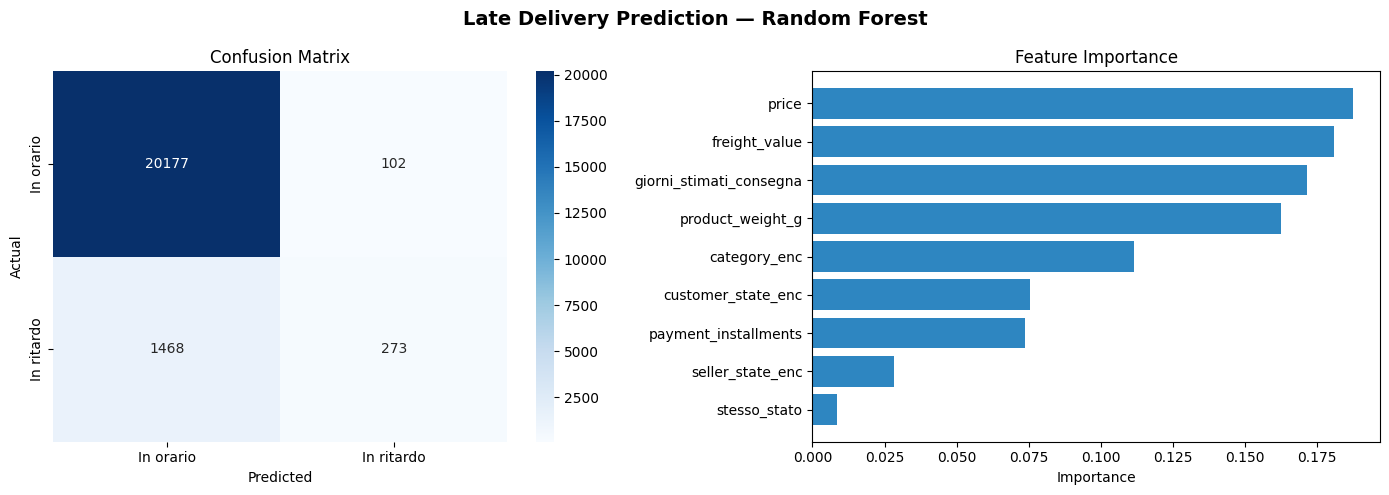

In [21]:
# ── Visualizzazioni risultati ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Late Delivery Prediction — Random Forest", fontsize=14, fontweight="bold")

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["In orario", "In ritardo"],
    yticklabels=["In orario", "In ritardo"]
)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ── Feature Importance ───────────────────────────────────────
feat_importance = pd.DataFrame({
    "feature":    features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)

axes[1].barh(
    feat_importance["feature"],
    feat_importance["importance"],
    color="#2E86C1"
)
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
#plt.savefig("output/ml_delivery_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

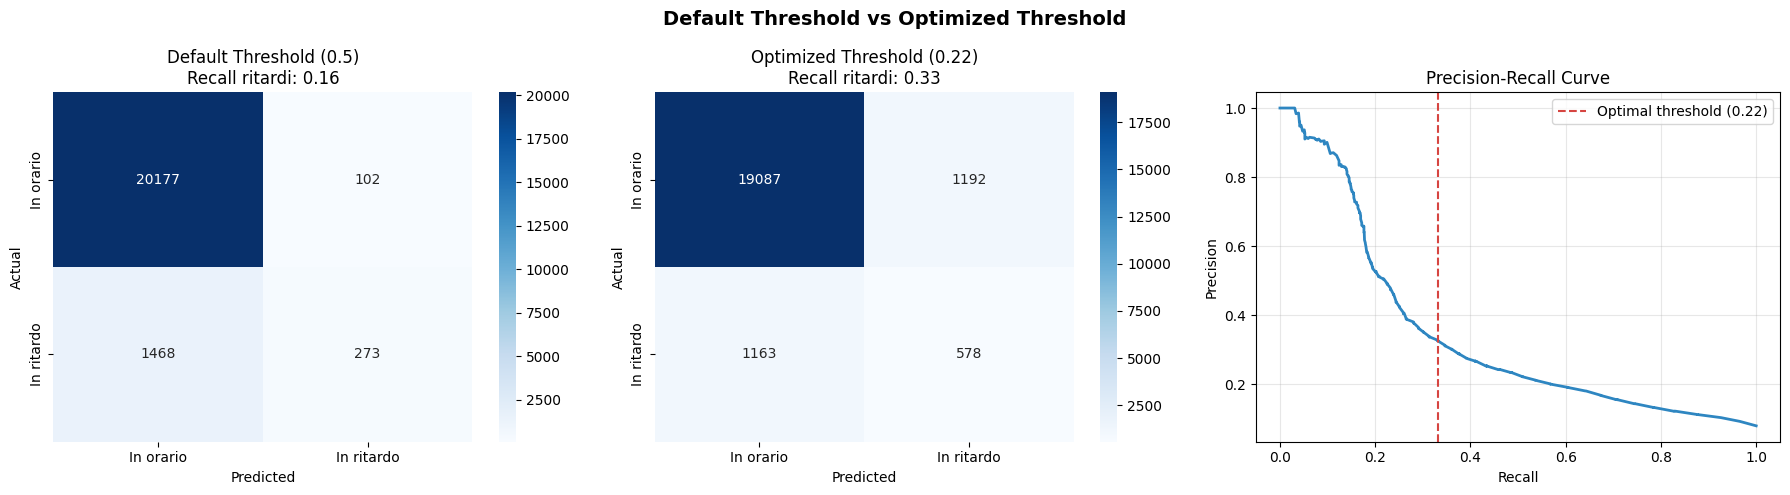

In [23]:
# ── Confronto soglia default vs ottimizzata ───────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Default Threshold vs Optimized Threshold", fontsize=14, fontweight="bold")

# ── Confusion Matrix — soglia default ────────────────────────
cm_default = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm_default,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["In orario", "In ritardo"],
    yticklabels=["In orario", "In ritardo"]
)
axes[0].set_title(f"Default Threshold (0.5)\nRecall ritardi: 0.16")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ── Confusion Matrix — soglia ottimizzata ────────────────────
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(
    cm_optimized,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["In orario", "In ritardo"],
    yticklabels=["In orario", "In ritardo"]
)
axes[1].set_title(f"Optimized Threshold ({best_threshold:.2f})\nRecall ritardi: 0.33")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

# ── Precision-Recall Curve ────────────────────────────────────
axes[2].plot(recalls, precisions, color="#2E86C1", linewidth=2)
axes[2].axvline(
    recalls[f1_scores.argmax()],
    color="#D64541",
    linestyle="--",
    label=f"Optimal threshold ({best_threshold:.2f})"
)
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("output/ml_threshold_comparison.png", dpi=150, bbox_inches="tight")
plt.show()